In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

p2p_data = pd.read_csv(r'/Users/tymek/Desktop/Regression case studies/P2P Data.csv')
p2p_data.shape

(391747, 11)

In [20]:
#Import the dmatrices function from the patsy module
from patsy import dmatrices

#Use this function to process categorical variables (string type)
Y,X = dmatrices('loan_status ~ grade + loan_amnt + term + home_ownership + annual_inc +  dti + delinq_2yrs + inq_last_6mths + total_acc', data = p2p_data, return_type = 'dataframe' )

#Note: The variable names in the newly generated dataset have changed.
#Use the .head() function to inspect the data
X.head()
Y.head()

,loan_status[Charged Off],loan_status[Fully Paid]
0,1.0,0.0
1,0.0,1.0
2,0.0,1.0
3,1.0,0.0
4,0.0,1.0


In [21]:
#Split the dataset into a training set and a test set
# Import the train_test_split function from sklearn
from sklearn.model_selection import train_test_split

# Split the dataset into training and test sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 12345)

In [22]:
# Import the statsmodels and pandas modules
import statsmodels.api as sm
import pandas as pd

# Build a logistic regression model and estimate the results
# (Note: select only one column from the Y matrix)
reg2_result = sm.Logit(y_train.iloc [:,1], X_train).fit()

# Display the regression results summary
reg2_result.summary()

Optimization terminated successfully.
         Current function value: 0.421084
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                              Logit Regression Results                             
===================================================================================
Dep. Variable:     loan_status[Fully Paid]   No. Observations:               313397
Model:                               Logit   Df Residuals:                   313381
Method:                                MLE   Df Model:                           15
Date:                     Wed, 08 Apr 2026   Pseudo R-squ.:                 0.07603
Time:                             18:11:37   Log-Likelihood:            -1.3197e+05
converged:                            True   LL-Null:                   -1.4283e+05
Covariance Type:                 nonrobust   LLR p-value:                     0.000
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  3.0528      0.028    108.526      0.000       2.998       3.108
grade[T.B]                -0.6460      0.023    -28.319      0.000      -0.691      -0.601
grade[T.C]                -1.0810      0.023    -47.737      0.000      -1.125      -1.037
grade[T.D]                -1.3863      0.024    -58.591      0.000      -1.433      -1.340
grade[T.E]                -1.6248      0.026    -61.600      0.000      -1.676      -1.573
grade[T.F]                -1.7141      0.032    -53.265      0.000      -1.777      -1.651
grade[T.G]                -1.9535      0.051    -38.304      0.000      -2.053      -1.854
term[T. 60 months]        -0.5435      0.013    -42.573      0.000      -0.568      -0.518
home_ownership[T.OWN]     -0.1276      0.018     -6.973      0.000      -0.164      -0.092
home_ownership[T.RENT]    -0.2603      0.011    -23.715      0.000      -0.282      -0.239
loan_amnt              -8.307e-06   7.59e-07    -10.942      0.000    -9.8e-06   -6.82e-06
annual_inc              3.618e-06   1.64e-07     22.100      0.000     3.3e-06    3.94e-06
dti                       -0.0163      0.001    -23.670      0.000      -0.018      -0.015
delinq_2yrs               -0.0300      0.006     -5.109      0.000      -0.042      -0.019
inq_last_6mths            -0.0624      0.005    -13.152      0.000      -0.072      -0.053
total_acc                  0.0021      0.000      4.354      0.000       0.001       0.003
==========================================================================================
"""

In [23]:

# Build a Probit regression model and estimate the results
#reg3_result = sm.Probit(y_train.iloc [: , 1], X_train).fit()

# Display the regression results summary
#reg3_result.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


              precision    recall  f1-score   support

        True       0.33      0.02      0.04     13263
       False       0.83      0.99      0.90     65087

    accuracy                           0.83     78350
   macro avg       0.58      0.51      0.47     78350
weighted avg       0.75      0.83      0.76     78350



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Text(0.5, 1.0, ' ROC ( On test set )')

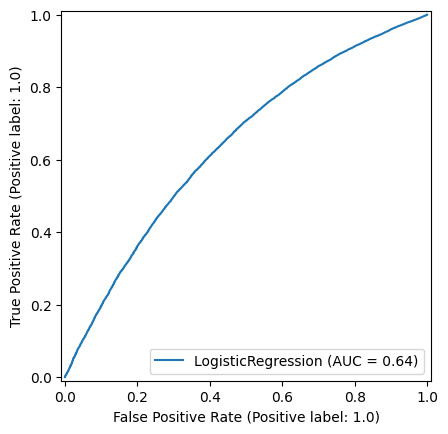

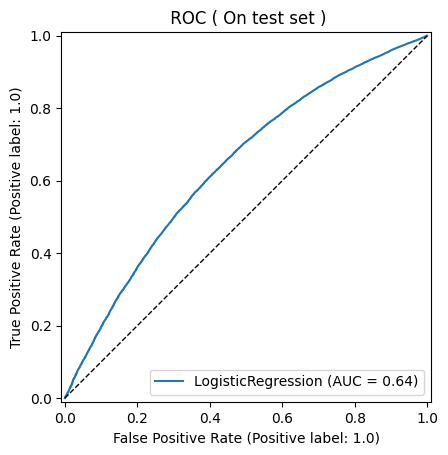

In [24]:
# Import sklearn and matplotlib modules
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay, cohen_kappa_score
#from sklearn.metrics import confusion_matrix, classification_report, plot_roc_curve, cohen_kappa_score

# Build and fit a Logistic Regression model (no regularization term)
# reg2 = LogisticRegression(penalty='none', fit_intercept=False)
reg2 = LogisticRegression(penalty=None, fit_intercept=False)
reg2.fit ( X_train, y_train.iloc [: , 1] )

# Plot the ROC curve using the trained model
RocCurveDisplay.from_estimator(reg2, X_test, y_test.iloc[:,1])

# Use the model to predict class probabilities for each observation
Probability = reg2.predict_proba ( X_test )
# Option 1: Use the built-in predict function to output class labels (threshold set automatically)
Prediction = reg2.predict ( X_test )

# Output the confusion matrix
confusion_matrix ( y_test.iloc [: , 1], Prediction )
# Output evaluation metrics based on the confusion matrix
print ( classification_report ( y_test.iloc [: , 1] , Prediction, target_names = ['True', 'False'] ) )

# Plot the ROC curve and compute AUC
#plot_roc_curve ( reg2, X_test,y_test.iloc [: , 1] )
RocCurveDisplay.from_estimator(reg2, X_test, y_test.iloc[:,1])
# Add a 45-degree reference line and set the title
x = np.linspace ( 0, 1, 100 )
plt.plot ( x, x, 'k--', linewidth = 1 )
plt.title (' ROC ( On test set )' )


In [25]:
confusion_matrix ( y_test.iloc [: , 1], Prediction )

array([[  268, 12995],
       [  555, 64532]])

In [26]:
#Import the balanced dataset
p2p_data_balance = pd.read_csv(r'/Users/tymek/Desktop/Regression case studies/P2P Data.csv')
p2p_data_balance.shape

(391747, 11)

In [27]:
#Use this function to process categorical variables of string type
Y2,X2 = dmatrices('loan_status ~ grade + loan_amnt + term + home_ownership + annual_inc +  dti + delinq_2yrs + inq_last_6mths + total_acc', data = p2p_data_balance, return_type = 'dataframe' )

In [28]:
#Split the dataset into training and test sets
from sklearn.model_selection import train_test_split
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, Y2, test_size = 0.15, random_state = 0)

              precision    recall  f1-score   support

        True       0.51      0.02      0.03     10047
       False       0.83      1.00      0.91     48716

    accuracy                           0.83     58763
   macro avg       0.67      0.51      0.47     58763
weighted avg       0.78      0.83      0.76     58763



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Text(0.5, 1.0, 'ROC (On test set)')

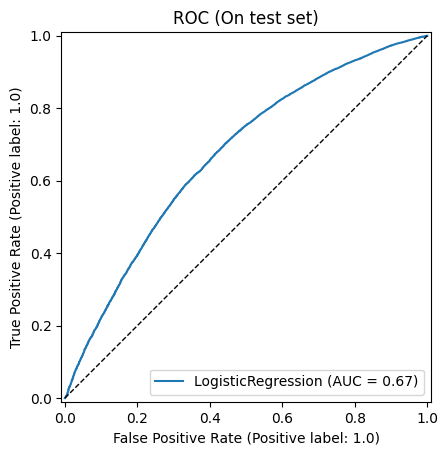

In [29]:
# Import required libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay

# Fit Logistic Regression model
reg5 = LogisticRegression(fit_intercept=False, solver='lbfgs', max_iter=1000)
reg5_result = reg5.fit(X_train2, y_train2.iloc[:, 1])

# Predict probabilities and class labels
Probability = reg5.predict_proba(X_test2)
Prediction = reg5.predict(X_test2)

# Confusion matrix
confusion_matrix(y_test2.iloc[:, 1], Prediction)
# Classification report
print(classification_report(y_test2.iloc[:, 1], Prediction, target_names=['True', 'False']))

# Plot ROC curve
RocCurveDisplay.from_estimator(reg5, X_test2, y_test2.iloc[:, 1])

# Add 45-degree reference line
x = np.linspace(0, 1, 100)
# Add title and show plot
plt.plot(x, x, 'k--', linewidth=1)
plt.title('ROC (On test set)')

In [30]:
confusion_matrix ( y_test2.iloc [: , 1], Prediction )

array([[  152,  9895],
       [  147, 48569]])